# Bivariate Analysis

#### Definition:
     Bivariate analysis examines two variables together to understand the relationship, association, or comparison between them.

#### Purpose:
     To explore how one variable changes with another and identify patterns such as correlation, dependence, trends, or group differences.

#### What Bivariate Analysis Explores (Unlike Univariate):
     Relationships , Associations , Interactions , Comparisons , Direction & strength of relationships

#### Why Bivariate Analysis Is Important:

     It helps us understand:
         1. Relationships Between Variables
             Does one variable increase when the other increases?
             Are they positively or negatively related?

        2. Group Differences
            Do different categories show different numerical patterns?
            Example: Income differences across education levels.

        3. Predictive Power
            Helps identify which variables may be useful predictors for modeling.

        4. Interaction Effects
            Some variables only show meaningful patterns when combined.

        5. Data Quality & Consistency
           Detects unexpected relationships or contradictions.
           
#### Types of Bivariate Analysis:

##### A. Numerical vs Numerical
         Used when both variables are continuous.

        Techniques:
            Correlation (Pearson, Spearman), Covariance, Simple Linear Regression
            
        Visualizations:
            Scatter Plot, Regression Line Plot, Heatmap (correlation matrix)
        Examples: Age vs Hours Worked, Education Years vs Income

##### B. Categorical vs Categorical
        Used when both variables are categorical.

        Techniques:
            Crosstab / Contingency Table, Chi‑Square Test of Independence, Proportional Analysis

        Visualizations:
            Grouped Bar Chart, Stacked Bar Chart, Mosaic Plot
            
        Examples: Workclass vs Income, Marital Status vs Income

##### C. Numerical vs Categorical
        Used when one variable is numeric and the other is categorical.

        Techniques:
            Grouped Summary Statistics (mean, median per category), ANOVA (Analysis of Variance), t‑tests (two groups)

        Visualizations:
            Box Plot, Violin Plot, Bar Plot with Error Bars , Strip Plot

        Examples: Income vs Education Level, Hours Worked vs Gender


#### Limitations of Bivariate Analysis
        1. Only Two Variables at a Time
            Cannot capture complex interactions involving multiple variables.

        2. Correlation ≠ Causation
            Even strong relationships do not imply one variable causes the other.

        3. Hidden Confounders
            A third variable may influence both variables being analyzed.

        4. Oversimplification
            Real-world data often requires multivariate analysis for deeper insights.

        5. Limited Predictive Insight
            Bivariate patterns alone cannot build robust predictive models.

#### Advantages
        1. Reveals Relationships Quickly
            Helps identify meaningful associations early in EDA.

        2. Guides Feature Engineering
            Detects variables worth transforming, encoding, or combining.

        3. Supports Hypothesis Testing
            Useful for statistical tests like correlation, chi-square, ANOVA.

        4. Easy to Visualize
            Scatter plots, box plots, and bar charts make patterns intuitive.

        5. Foundation for Multivariate Analysis
            Helps decide which variables to include in modeling.

#### Disadvantages
        1. Cannot Capture Complex Interactions
            Real datasets often involve multiple variables influencing each other.

        2. Misleading Without Context
            A relationship may disappear or reverse when other variables are considered.

        3. Sensitive to Outliers
            Outliers can distort correlations and regression lines.

        4. Limited for High-Dimensional Data
            Not scalable when datasets have many variables.


### Conclusion: 

        Bivariate analysis studies two variables together to understand their relationship, association, or group differences. It provides insights into correlations, trends, and interactions that univariate analysis cannot reveal. However, it still cannot explain causation or capture complex multi-variable patterns. Therefore, bivariate analysis is a crucial middle step between univariate exploration and full multivariate modeling.


























In [59]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations

import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Statistical visualizations

import plotly.express as px       # Interactive plots (histograms, bar charts)

In [60]:
df = pd.read_csv("df_train_test.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,1,0,2174,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,0,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,0,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,0,0,0


Text(0.5, 1.0, 'Education vs Education_num')

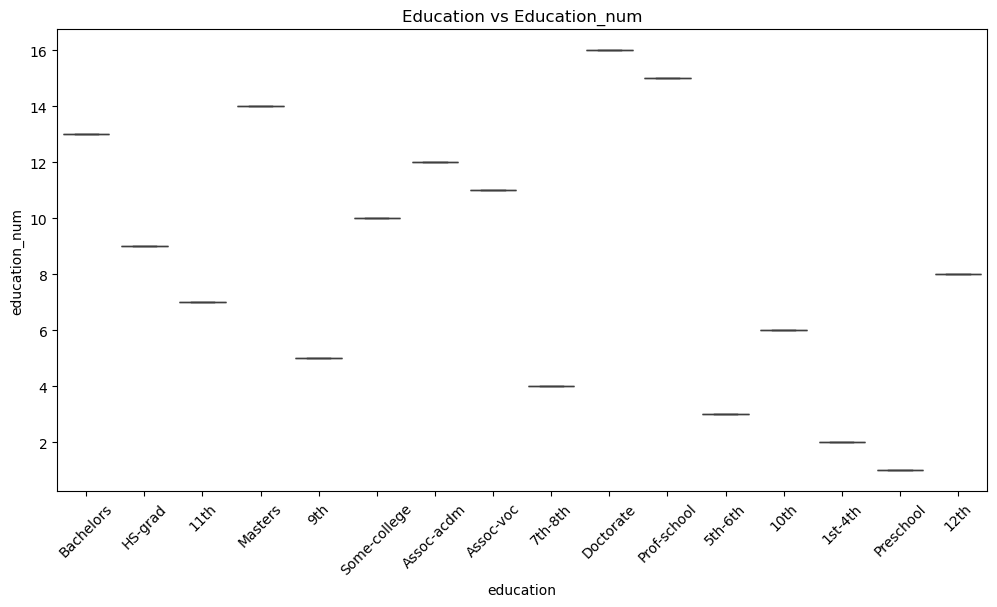

In [61]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='education', y='education_num')
plt.xticks(rotation=45)
plt.title("Education vs Education_num")


#### Every education category corresponds to one unique numeric value.

#### There is no overlap, no variation, and no randomness in the mapping.

#### The relationship is strictly one‑to‑one

In [62]:
df[['education', 'education_num']].drop_duplicates().sort_values('education_num')


,education,education_num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


In [67]:
X.dtypes


education_num    int64
11th              bool
12th              bool
1st-4th           bool
5th-6th           bool
7th-8th           bool
9th               bool
Assoc-acdm        bool
Assoc-voc         bool
Bachelors         bool
Doctorate         bool
HS-grad           bool
Masters           bool
Preschool         bool
Prof-school       bool
Some-college      bool
dtype: object

## Variance Inflation Factor (VIF)
#### Variance Inflation Factor (VIF) measures how much the variance of a regression coefficient is inflated due to multicollinearity among predictors. It is defined as:

$$
\text{VIF} = \frac{1}{1 - R^{2}}
$$

Interpretation of VIF values
VIF = 1 — No multicollinearity

VIF > 5 — Moderate multicollinearity

VIF > 10 — Severe multicollinearity

VIF = ∞ — Perfect multicollinearity

Application to education and education_num
In the Adult dataset, education_num is a deterministic ordinal encoding of the categorical variable education. Each education category maps to exactly one numeric value. Because of this one‑to‑one relationship:

The dummy variables created from education can perfectly predict education_num.

The resulting 
$
\text R^{2}
$
 is extremely high.

The VIF for education_num becomes very large (often >100).

Several education dummy variables also show high VIF values.


In [73]:
X = X.astype(int)
X.dtypes

education_num    int64
11th             int64
12th             int64
1st-4th          int64
5th-6th          int64
7th-8th          int64
9th              int64
Assoc-acdm       int64
Assoc-voc        int64
Bachelors        int64
Doctorate        int64
HS-grad          int64
Masters          int64
Preschool        int64
Prof-school      int64
Some-college     int64
dtype: object

In [70]:
X = X.apply(lambda col: col.astype(int))


In [71]:
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif


,feature,VIF
0,education_num,105.609251
1,11th,2.775618
2,12th,1.839613
3,1st-4th,1.019598
4,5th-6th,1.091433
5,7th-8th,1.305256
6,9th,1.377970
7,Assoc-acdm,5.610511
8,Assoc-voc,5.984801
9,Bachelors,28.105432


#### Conclusion: 
The VIF results confirm perfect or near‑perfect multicollinearity between education and education_num. Since both variables contain the same information, only one of them should be included in any regression model—typically education_num.

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, 'Unknown'),
  Text(6, 0, 'Self-emp-inc'),
  Text(7, 0, 'Without-pay'),
  Text(8, 0, 'Never-worked')])

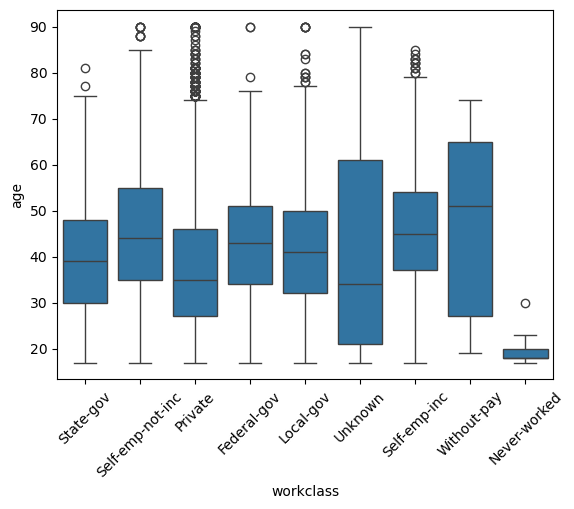

In [72]:
sns.boxplot(data=df, x='workclass', y='age')
plt.xticks(rotation=45)


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, 'Unknown'),
  Text(6, 0, 'Self-emp-inc'),
  Text(7, 0, 'Without-pay'),
  Text(8, 0, 'Never-worked')])

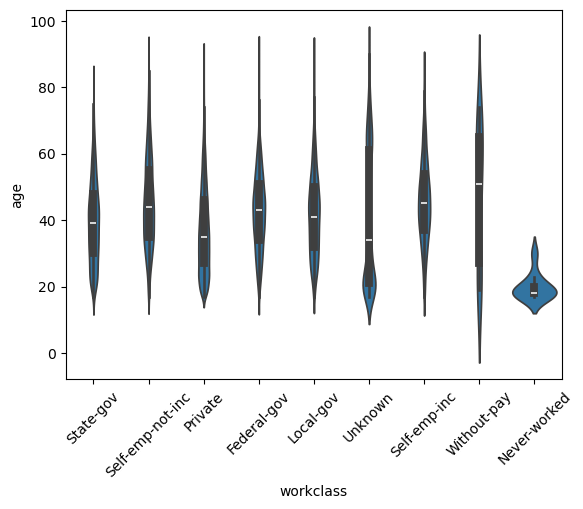

In [6]:
sns.violinplot(data=df, x='workclass', y='age')
plt.xticks(rotation=45)


# 1. Age(Numerical) Vs Income (Categorical)

#### Do Older Individuals tends to earn more?

In [7]:
df.groupby('income')['age'].describe()


,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37128.0,36.875916,14.102678,17.0,25.0,34.0,46.0,90.0
>50K,11685.0,44.275909,10.559706,19.0,36.0,43.0,51.0,90.0


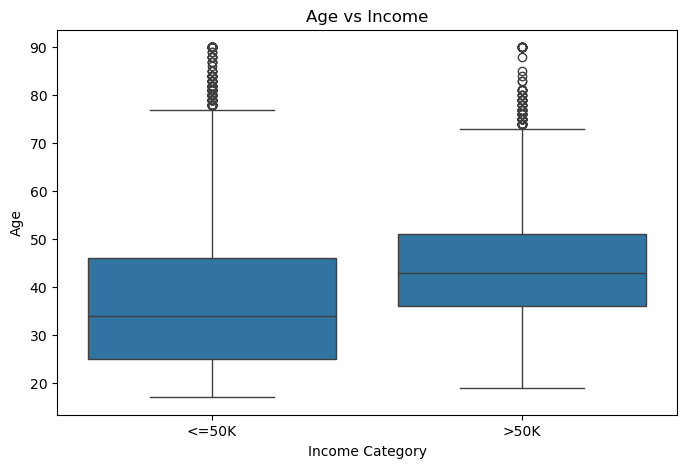

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='income', y='age')
plt.title("Age vs Income")
plt.xlabel("Income Category")
plt.ylabel("Age")
plt.show()


In [11]:
corr = df[['age', 'income_binary']].corr().iloc[0,1] 
corr

np.float64(0.2303347705502954)

In [23]:
from scipy.stats import ttest_ind

group_low  = df[df['income'] == '<=50K']['age']
group_high = df[df['income'] == '>50K']['age']

t_stat, p_value = ttest_ind(group_low, group_high, equal_var=False)  # Welch's t-test
t_stat, p_value


(np.float64(-60.624055717073034), np.float64(0.0))

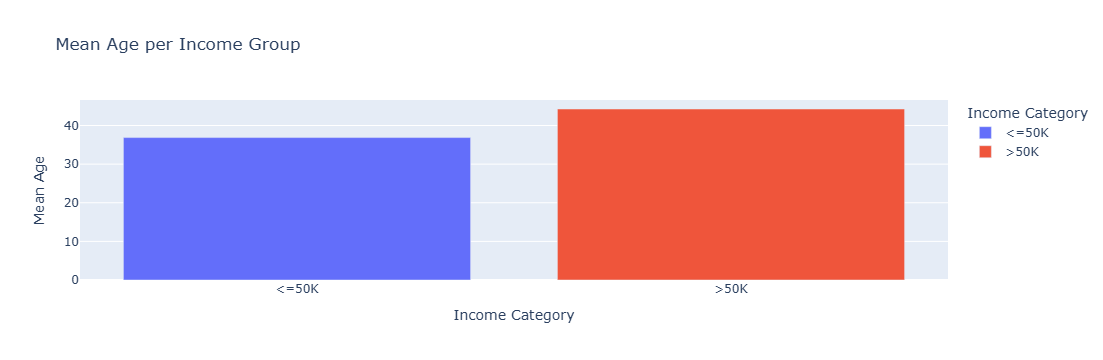

In [24]:


mean_age = df.groupby('income')['age'].mean().reset_index()

fig = px.bar(
    mean_age,
    x='income',
    y='age',
    color='income',
    title='Mean Age per Income Group',
    labels={'income': 'Income Category', 'age': 'Mean Age'},
    hover_data={'age': ':.2f'}  # show age with 2 decimal places
)

fig.show()


# 2. workclass vs income

In [12]:
pd.crosstab(df['workclass'], df['income'])


income,<=50K,>50K
workclass,,
Federal-gov,871,561
Local-gov,2209,927
Never-worked,10,0
Private,26494,7385
Self-emp-inc,756,938
Self-emp-not-inc,2784,1077
State-gov,1451,530
Unknown,2534,265
Without-pay,19,2


In [13]:
pd.crosstab(df['workclass'], df['income'], normalize='index') * 100


income,<=50K,>50K
workclass,,
Federal-gov,60.824022,39.175978
Local-gov,70.440051,29.559949
Never-worked,100.000000,0.000000
Private,78.201836,21.798164
Self-emp-inc,44.628099,55.371901
Self-emp-not-inc,72.105672,27.894328
State-gov,73.245835,26.754165
Unknown,90.532333,9.467667
Without-pay,90.476190,9.523810


In [28]:
df['workclass_grouped'] = df['workclass'].replace({
    'Federal-gov': 'Government',
    'State-gov': 'Government',
    'Local-gov': 'Government',
    'Self-emp-inc': 'Self-Employed',
    'Self-emp-not-inc': 'Self-Employed',
    'Without-pay': 'Not-Working',
    'Never-worked': 'Not-Working',
    'Unknown': 'Unknown',
    'Private': 'Private'
})

pd.crosstab(df['workclass_grouped'], df['income'])



income,<=50K,>50K
workclass_grouped,,
Government,69.186135,30.813865
Not-Working,93.548387,6.451613
Private,78.201836,21.798164
Self-Employed,63.726373,36.273627
Unknown,90.532333,9.467667


In [30]:
from tabulate import tabulate


table = pd.crosstab(
    df['workclass_grouped'],
    df['income'],
    normalize='index'
) * 100

# Format to 2 decimals + % sign
table_fmt = table.round(2).astype(str) + '%'

print(tabulate(table_fmt, headers='keys', tablefmt='grid'))


+---------------------+---------+--------+
| workclass_grouped   | <=50K   | >50K   |
+=====================+=========+========+
| Government          | 69.19%  | 30.81% |
+---------------------+---------+--------+
| Not-Working         | 93.55%  | 6.45%  |
+---------------------+---------+--------+
| Private             | 78.2%   | 21.8%  |
+---------------------+---------+--------+
| Self-Employed       | 63.73%  | 36.27% |
+---------------------+---------+--------+
| Unknown             | 90.53%  | 9.47%  |
+---------------------+---------+--------+


In [32]:
from tabulate import tabulate
import pandas as pd

# Crosstab with row percentages
table = pd.crosstab(
    df['workclass_grouped'],
    df['income'],
    normalize='index'
) * 100

# Format to 2 decimals + % sign
table_fmt = table.round(2).astype(str) + '%'

# Build a new table with an extra header row
header_row = ['workclass_grouped', 'Income', 'Income']   # spans visually
table_with_header = table_fmt.reset_index()

# Print table with lines
print(tabulate(
    table_with_header,
    headers=header_row,
    tablefmt='grid'
))



+----+---------------------+----------+----------+
|    | workclass_grouped   | Income   | Income   |
+====+=====================+==========+==========+
|  0 | Government          | 69.19%   | 30.81%   |
+----+---------------------+----------+----------+
|  1 | Not-Working         | 93.55%   | 6.45%    |
+----+---------------------+----------+----------+
|  2 | Private             | 78.2%    | 21.8%    |
+----+---------------------+----------+----------+
|  3 | Self-Employed       | 63.73%   | 36.27%   |
+----+---------------------+----------+----------+
|  4 | Unknown             | 90.53%   | 9.47%    |
+----+---------------------+----------+----------+


+----+---------------------+----------+----------+
|    | workclass_grouped   | Income   | Income   |
+====+=====================+==========+==========+
|  0 | Government          | 69.19%   | 30.81%   |
+----+---------------------+----------+----------+
|  1 | Not-Working         | 93.55%   | 6.45%    |
+----+---------------------+----------+----------+
|  2 | Private             | 78.2%    | 21.8%    |
+----+---------------------+----------+----------+
|  3 | Self-Employed       | 63.73%   | 36.27%   |
+----+---------------------+----------+----------+
|  4 | Unknown             | 90.53%   | 9.47%    |
+----+---------------------+----------+----------+


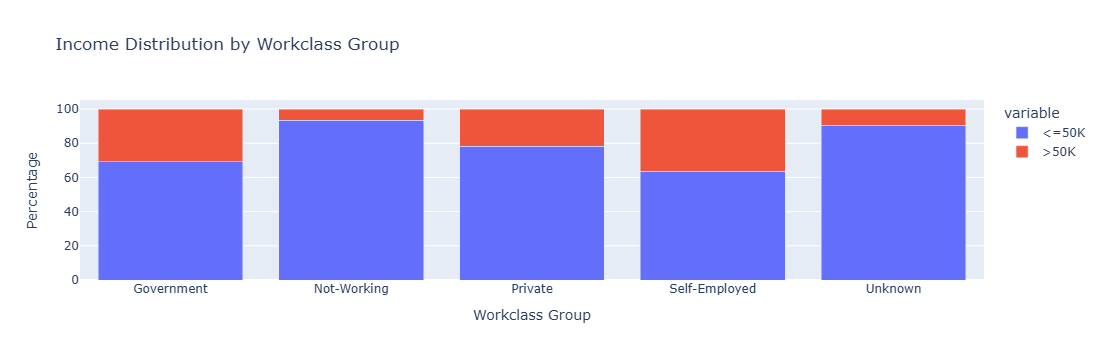

In [34]:
from tabulate import tabulate

# Crosstab with row percentages
table = pd.crosstab(
    df['workclass_grouped'],
    df['income'],
    normalize='index'
) * 100

# Format to 2 decimals + % sign
table_fmt = table.round(2).astype(str) + '%'

# Build a new table with an extra header row
header_row = ['workclass_grouped', 'Income', 'Income']
table_with_header = table_fmt.reset_index()

# Print table with lines
print(tabulate(
    table_with_header,
    headers=header_row,
    tablefmt='grid'
))

# ---------------------------------------
# 📊 HOVER-ENABLED STACKED BAR CHART HERE
# ---------------------------------------

fig = px.bar(
    table.reset_index(),
    x='workclass_grouped',
    y=['<=50K', '>50K'],
    title="Income Distribution by Workclass Group",
    labels={'value': 'Percentage', 'workclass_grouped': 'Workclass Group'},
    barmode='stack'
)

fig.update_traces(hovertemplate='%{y:.2f}%')

fig.show()


# 3. age vs hours_per_week

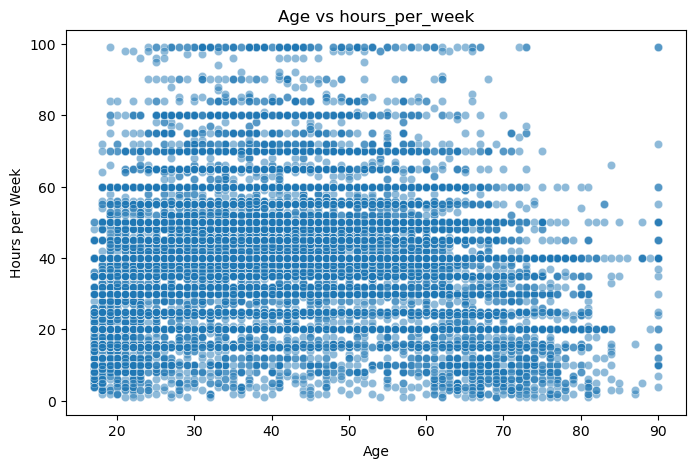

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='hours_per_week', alpha=0.5)
plt.title("Age vs hours_per_week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()


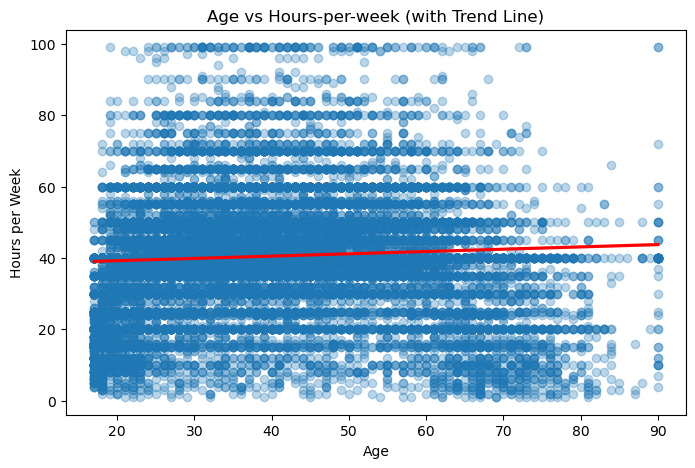

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='age', y='hours_per_week',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Age vs Hours-per-week (with Trend Line)")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()


In [19]:
corr = df['age'].corr(df['hours_per_week'])
corr


np.float64(0.07132173112293383)

#### The Pearson correlation between age and hours_per_week is 0.071, indicating a very weak positive linear relationship. This means age has almost no influence on the number of hours a person works per week. The scatter plot supports this result, showing a diffuse cloud of points with no clear trend. Overall, age is not a strong predictor of weekly working hours in this dataset.

### 4. education vs income

In [36]:
df['education_grouped'] = df['education'].replace({
    'Preschool': 'Lower-Education',
    '1st-4th': 'Lower-Education',
    '5th-6th': 'Lower-Education',
    '7th-8th': 'Lower-Education',
    '9th': 'Lower-Education',
    '10th': 'Lower-Education',
    '11th': 'Lower-Education',
    '12th': 'Lower-Education',
    'HS-grad': 'High-School',
    'Some-college': 'Some-College',
    'Assoc-acdm': 'Associates',
    'Assoc-voc': 'Associates',
    'Bachelors': 'Bachelors',
    'Masters': 'Advanced-Degree',
    'Doctorate': 'Advanced-Degree',
    'Prof-school': 'Advanced-Degree'
})


In [37]:
# 1. Crosstab (Counts)
ct_counts = pd.crosstab(df['education_grouped'], df['income'])
ct_counts


income,<=50K,>50K
education_grouped,,
Advanced-Degree,1577,2507
Associates,2726,935
Bachelors,4707,3313
High-School,13275,2502
Lower-Education,6036,366
Some-College,8807,2062


In [38]:
# Row percentage cross-tab

ct_percent = pd.crosstab(
    df['education_grouped'],
    df['income'],
    normalize='index'
) * 100

ct_percent = ct_percent.round(2)
ct_percent


income,<=50K,>50K
education_grouped,,
Advanced-Degree,38.61,61.39
Associates,74.46,25.54
Bachelors,58.69,41.31
High-School,84.14,15.86
Lower-Education,94.28,5.72
Some-College,81.03,18.97


In [39]:
# Chi2 test

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_counts)

print("Chi-square value:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)


Chi-square value: 6359.983211109433
p-value: 0.0
Degrees of freedom: 5


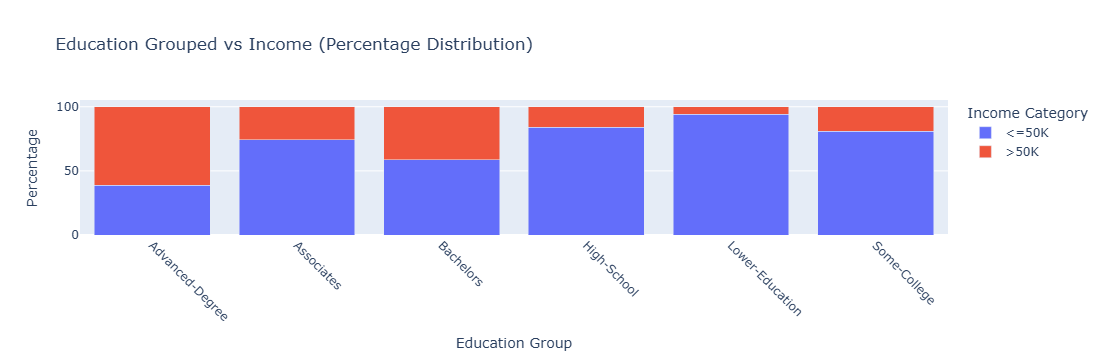

In [40]:


# Reset index so Plotly can use columns
ct_plot = ct_percent.reset_index()

fig = px.bar(
    ct_plot,
    x='education_grouped',
    y=['<=50K', '>50K'],
    title="Education Grouped vs Income (Percentage Distribution)",
    labels={'value': 'Percentage', 'education_grouped': 'Education Group'},
    barmode='stack'
)

# Hover formatting
fig.update_traces(hovertemplate='%{y:.2f}%')

fig.update_layout(
    xaxis_tickangle=45,
    legend_title_text='Income Category'
)

fig.show()


In [43]:
# Education Vs Hours_per_week

# 1. Summary statistics of hours-per-week by education group (including mode)
summary_stats = df.groupby('education_grouped')['hours_per_week'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

# Add mode separately (mode can return multiple values, so take the first)
mode_values = df.groupby('education_grouped')['hours_per_week'].agg(lambda x: x.mode().iloc[0])

# Add mode column to summary_stats
summary_stats['mode'] = mode_values

summary_stats



,count,mean,median,std,min,max,mode
education_grouped,,,,,,,
Advanced-Degree,4084,44.83,40.0,13.31,1,99,40
Associates,3661,41.29,40.0,11.52,1,99,40
Bachelors,8020,42.48,40.0,11.43,1,99,40
High-School,15777,40.64,40.0,11.43,1,99,40
Lower-Education,6402,36.64,40.0,13.50,1,99,40
Some-College,10869,38.88,40.0,12.79,1,99,40


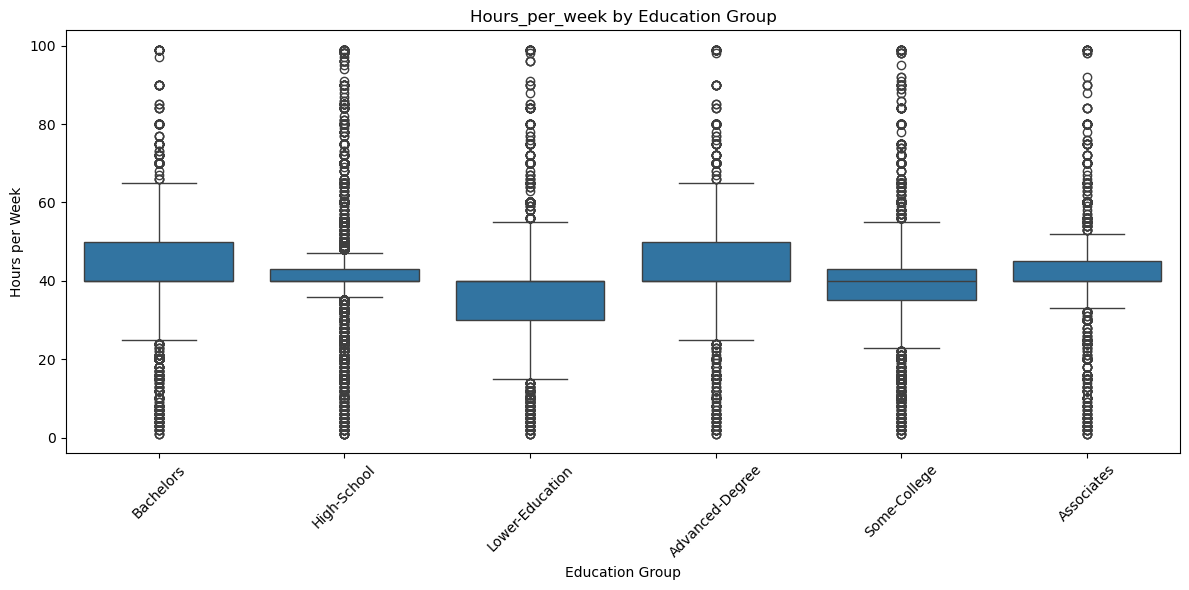

In [46]:


plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='education_grouped',
    y='hours_per_week'
)

plt.title("Hours_per_week by Education Group")
plt.xlabel("Education Group")
plt.ylabel("Hours per Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


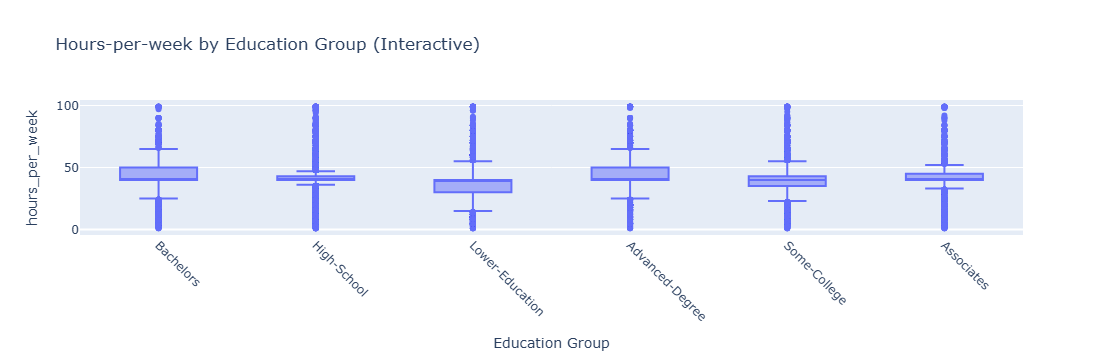

In [47]:


fig = px.box(
    df,
    x='education_grouped',
    y='hours_per_week',
    title="Hours-per-week by Education Group (Interactive)",
    labels={'education_grouped': 'Education Group', 'hours-per-week': 'Hours per Week'}
)

fig.update_traces(hovertemplate='Hours: %{y}')
fig.update_layout(xaxis_tickangle=45)

fig.show()


In [48]:
from scipy.stats import f_oneway

groups = [group['hours_per_week'].values 
          for name, group in df.groupby('education_grouped')]

anova_stat, p_value = f_oneway(*groups)

print("ANOVA F-statistic:", round(anova_stat, 4))
print("p-value:", round(p_value, 6))


ANOVA F-statistic: 315.1965
p-value: 0.0


In [49]:
# workclass vs education
ct_counts = pd.crosstab(df['workclass'], df['education_grouped'])
ct_counts


education_grouped,Advanced-Degree,Associates,Bachelors,High-School,Lower-Education,Some-College
workclass,,,,,,
Federal-gov,170,142,313,395,49,363
Local-gov,602,253,700,761,231,589
Never-worked,0,0,0,2,6,2
Private,1999,2572,5298,11675,4808,7527
Self-emp-inc,296,117,418,426,105,332
Self-emp-not-inc,479,282,607,1279,491,723
State-gov,429,138,431,415,78,490
Unknown,109,155,253,810,632,840
Without-pay,0,2,0,14,2,3


In [50]:
ct_counts_1= pd.crosstab(df['workclass_grouped'], df['education_grouped'])
ct_counts_1

education_grouped,Advanced-Degree,Associates,Bachelors,High-School,Lower-Education,Some-College
workclass_grouped,,,,,,
Government,1201,533,1444,1571,358,1442
Not-Working,0,2,0,16,8,5
Private,1999,2572,5298,11675,4808,7527
Self-Employed,775,399,1025,1705,596,1055
Unknown,109,155,253,810,632,840


In [51]:
ct_percent = pd.crosstab(
    df['workclass'],
    df['education_grouped'],
    normalize='index'
) * 100

ct_percent = ct_percent.round(2)
ct_percent


education_grouped,Advanced-Degree,Associates,Bachelors,High-School,Lower-Education,Some-College
workclass,,,,,,
Federal-gov,11.87,9.92,21.86,27.58,3.42,25.35
Local-gov,19.20,8.07,22.32,24.27,7.37,18.78
Never-worked,0.00,0.00,0.00,20.00,60.00,20.00
Private,5.90,7.59,15.64,34.46,14.19,22.22
Self-emp-inc,17.47,6.91,24.68,25.15,6.20,19.60
Self-emp-not-inc,12.41,7.30,15.72,33.13,12.72,18.73
State-gov,21.66,6.97,21.76,20.95,3.94,24.73
Unknown,3.89,5.54,9.04,28.94,22.58,30.01
Without-pay,0.00,9.52,0.00,66.67,9.52,14.29


In [52]:
ct_percent1 = pd.crosstab(
    df['workclass_grouped'],
    df['education_grouped'],
    normalize='index'
) * 100

ct_percent1 = ct_percent1.round(2)
ct_percent1


education_grouped,Advanced-Degree,Associates,Bachelors,High-School,Lower-Education,Some-College
workclass_grouped,,,,,,
Government,18.34,8.14,22.05,23.99,5.47,22.02
Not-Working,0.00,6.45,0.00,51.61,25.81,16.13
Private,5.90,7.59,15.64,34.46,14.19,22.22
Self-Employed,13.95,7.18,18.45,30.69,10.73,18.99
Unknown,3.89,5.54,9.04,28.94,22.58,30.01


In [53]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_counts)

print("Chi-square value:", round(chi2, 4))
print("p-value:", round(p, 6))
print("Degrees of freedom:", dof)


Chi-square value: 2763.092
p-value: 0.0
Degrees of freedom: 40


In [54]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_counts_1)

print("Chi-square value:", round(chi2, 4))
print("p-value:", round(p, 6))
print("Degrees of freedom:", dof)


Chi-square value: 2421.8748
p-value: 0.0
Degrees of freedom: 20
